In [1]:

!pip install pyspark

from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("BankaMusteriAnalizi").getOrCreate()

In [4]:

dosya_yolu = "/content/sample_data/Bank Customer Churn Prediction.csv"


df = spark.read.csv(dosya_yolu, header=True, inferSchema=True)

df.printSchema()
df.show(5)

root
 |-- customer_id: integer (nullable = true)
 |-- credit_score: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- balance: double (nullable = true)
 |-- products_number: integer (nullable = true)
 |-- credit_card: integer (nullable = true)
 |-- active_member: integer (nullable = true)
 |-- estimated_salary: double (nullable = true)
 |-- churn: integer (nullable = true)

+-----------+------------+-------+------+---+------+---------+---------------+-----------+-------------+----------------+-----+
|customer_id|credit_score|country|gender|age|tenure|  balance|products_number|credit_card|active_member|estimated_salary|churn|
+-----------+------------+-------+------+---+------+---------+---------------+-----------+-------------+----------------+-----+
|   15634602|         619| France|Female| 42|     2|      0.0|              1|          1|            1|  

In [5]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

indexer = StringIndexer(inputCols=["country", "gender"], outputCols=["country_index", "gender_index"])
df_indexed = indexer.fit(df).transform(df)


required_columns = ["credit_score", "country_index", "gender_index", "age", "tenure",
                    "balance", "products_number", "credit_card", "active_member", "estimated_salary"]


assembler = VectorAssembler(inputCols=required_columns, outputCol="features")
final_data = assembler.transform(df_indexed)

final_data = final_data.select("features", "churn")
final_data.show(5)

+--------------------+-----+
|            features|churn|
+--------------------+-----+
|[619.0,0.0,1.0,42...|    1|
|[608.0,2.0,1.0,41...|    0|
|[502.0,0.0,1.0,42...|    1|
|[699.0,0.0,1.0,39...|    0|
|[850.0,2.0,1.0,43...|    0|
+--------------------+-----+
only showing top 5 rows


In [6]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


train_data, test_data = final_data.randomSplit([0.8, 0.2], seed=42)


rf = RandomForestClassifier(labelCol="churn", featuresCol="features", numTrees=10)

rf_model = rf.fit(train_data)


predictions = rf_model.transform(test_data)


predictions.select("prediction", "churn").show(10)

+----------+-----+
|prediction|churn|
+----------+-----+
|       0.0|    0|
|       0.0|    0|
|       1.0|    1|
|       0.0|    1|
|       0.0|    0|
|       1.0|    1|
|       0.0|    1|
|       0.0|    0|
|       0.0|    0|
|       0.0|    0|
+----------+-----+
only showing top 10 rows


In [7]:

from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics


evaluator = MulticlassClassificationEvaluator(labelCol="churn", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)


f1_evaluator = MulticlassClassificationEvaluator(labelCol="churn", predictionCol="prediction", metricName="f1")
f1_score = f1_evaluator.evaluate(predictions)

print(f"Modelin Doğruluk Oranı (Accuracy): {accuracy:.4f}")
print(f"Modelin F1 Skoru: {f1_score:.4f}")

predictionAndLabels = predictions.select("prediction", "churn").rdd.map(lambda x: (float(x[0]), float(x[1])))
metrics = MulticlassMetrics(predictionAndLabels)

print("\nHata Matrisi (Confusion Matrix):")
print(metrics.confusionMatrix().toArray())

Modelin Doğruluk Oranı (Accuracy): 0.8501
Modelin F1 Skoru: 0.8280


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



Hata Matrisi (Confusion Matrix):
[[1482.   38.]
 [ 250.  151.]]


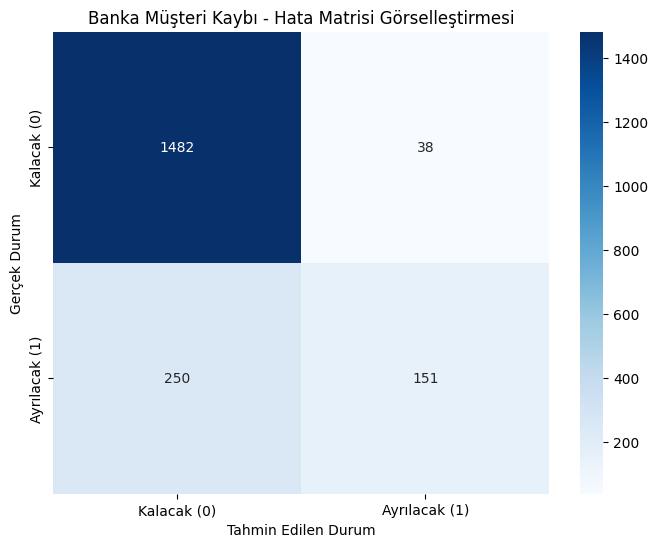

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


conf_matrix = np.array([[1482, 38], [250, 151]])


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Kalacak (0)', 'Ayrılacak (1)'],
            yticklabels=['Kalacak (0)', 'Ayrılacak (1)'])

plt.xlabel('Tahmin Edilen Durum')
plt.ylabel('Gerçek Durum')
plt.title('Banka Müşteri Kaybı - Hata Matrisi Görselleştirmesi')
plt.show()

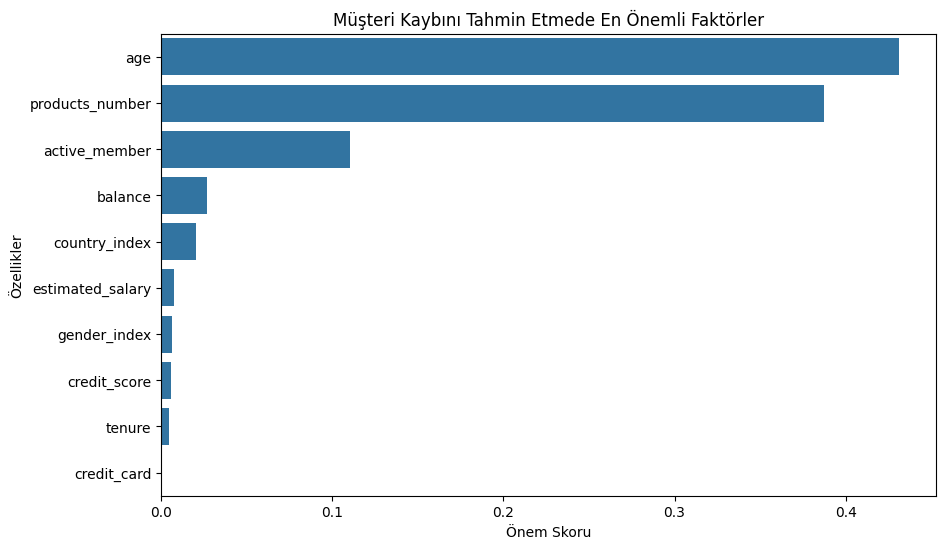

In [9]:

import pandas as pd

importances = rf_model.featureImportances
feature_list = required_columns
feature_imp = pd.Series(importances.toArray(), index=feature_list).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.title("Müşteri Kaybını Tahmin Etmede En Önemli Faktörler")
plt.xlabel("Önem Skoru")
plt.ylabel("Özellikler")
plt.show()